# Analisis Data Penyewaan Sepeda sebagai Bagian dari Smart City

**Mata Kuliah:** Statistika dan Probabilitas
**Project:** Proyek 1 — Exploratory Data Analysis (EDA)
**Topik:** Smart City
**Dataset:** UCI Bike Sharing — `bikesharing\_dataset.csv`

**Kelompok:** Kelompok 8

**Anggota Kelompok:**
- Muhammad Zakir Zaid Arif — 5027261103
- Jihan Safira — 5027261087
- Fikri Tri Ardiansyah — 5027261021

## [1] Latar Belakang dan Pertanyaan

Bike sharing merupakan salah satu bentuk mobilitas perkotaan yang menghasilkan data mengenai penggunaan transportasi dalam kehidupan sehari-hari. Data tersebut menarik untuk dianalisis dalam konteks Smart City karena dapat menggambarkan pola permintaan terhadap layanan mobilitas kota.

Kami menggunakan **Bike Sharing Dataset** dari UCI Machine Learning Repository, khususnya file `bikesharing\_dataset.csv`, yang berisi data harian sistem Capital Bikeshare selama tahun 2011–2012. Setiap baris mewakili satu hari dan memuat informasi mengenai jumlah penyewaan sepeda, musim, kalender, serta kondisi cuaca.

### Pertanyaan Analisis

1. Bagaimana pusat dan penyebaran jumlah penyewaan sepeda (`cnt`) dalam satu hari?
2. Bagaimana jumlah penyewaan berbeda menurut musim (`season`)?
3. Bagaimana pola hubungan yang terlihat antara suhu normalisasi (`temp`) dan jumlah penyewaan (`cnt`)?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/day_dataset.csv") 

print("Ukuran data:", df.shape)

df.head()

Ukuran data: (731, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


### Interpretasi Pemuatan Data

`pd.read\_csv()` digunakan untuk membaca file CSV menjadi DataFrame pandas. Variabel `df` digunakan sebagai nama DataFrame agar kode berikutnya lebih mudah ditulis.

`df.shape` menunjukkan ukuran data dalam bentuk `(jumlah\_baris, jumlah\_kolom)`.

Untuk dataset `bikesharing\_dataset.csv`, ukuran data adalah **(731, 16)**.

Artinya terdapat **731 baris atau observasi** dan **16 kolom atau variabel**.

Satu baris pada dataset mewakili **satu hari pengamatan**.

## [2] Deskripsi Data dan Kamus Data

Sumber dataset: **UCI Machine Learning Repository — Bike Sharing Dataset**

URL: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

DOI: https://doi.org/10.24432/C5W894

Lisensi: **CC BY 4.0**

Dataset berisi informasi mengenai penyewaan sepeda pada sistem Capital Bikeshare, beserta informasi kalender, musim, dan kondisi cuaca. Pada proyek ini digunakan file `bikesharing\_dataset.csv`.

### Unit Observasi

**1 baris = 1 hari.**

In [3]:
df.info()

print("\nJumlah missing value per kolom:")
print(df.isna().sum())

print("\nJumlah baris duplikat:")
print(df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 98.6 KB

Jumlah missing value per kolom:
instant       0
dteday        0
season        0
yr            0
mnth       

### Interpretasi Pemeriksaan Kualitas Data

`df.info()` digunakan untuk melihat informasi setiap kolom, termasuk tipe data dan jumlah data yang terbaca.

`df.isna().sum()` digunakan untuk menghitung jumlah **missing value** atau data kosong pada setiap kolom.

`df.duplicated().sum()` digunakan untuk menghitung jumlah baris yang identik atau duplikat.

Berdasarkan hasil pemeriksaan pada dataset, tidak ditemukan missing value dan tidak ditemukan baris duplikat identik.

Karena tidak ditemukan masalah tersebut, seluruh observasi tetap digunakan dalam analisis.


## [3] Label Kategori `season`

Kolom `season` menggunakan kode angka. Agar hasil analisis dan visualisasi lebih mudah dipahami, kode tersebut diterjemahkan menjadi label musim.

Pemetaan yang digunakan:

- 1 = Winter
- 2 = Spring
- 3 = Summer
- 4 = Fall

In [7]:
season_map = {
    1: "Winter",
    2: "Spring",
    3: "Summer",
    4: "Fall"
}

df["season_label"] = df["season"].map(season_map)

df[["season", "season_label"]].drop_duplicates().sort_values("season")

,season,season_label
0,1,Winter
79,2,Spring
171,3,Summer
265,4,Fall


### Interpretasi

Kolom `season\_label` dibuat untuk mempermudah pembacaan hasil analisis dan visualisasi.

Kolom asli `season` tetap dipertahankan, sehingga data aslinya tidak diubah.

## [4] Statistik Deskriptif Variabel Numerik

Tiga variabel numerik utama yang dianalisis adalah:

- `temp` — suhu normalisasi
- `hum` — kelembapan normalisasi
- `cnt` — total penyewaan sepeda per hari

Untuk setiap variabel dihitung:

- mean
- median
- modus
- minimum
- maksimum
- range
- varians
- simpangan baku
- Q1
- Q3
- IQR

In [8]:
kolom_numerik = ["temp", "hum", "cnt"]

hasil_statistik = []

for nama in kolom_numerik:
    kolom = df[nama]
    q1 = kolom.quantile(0.25)
    q3 = kolom.quantile(0.75)

    hasil_statistik.append({
        "Variabel": nama,
        "Mean": kolom.mean(),
        "Median": kolom.median(),
        "Modus": list(kolom.mode()),
        "Minimum": kolom.min(),
        "Maksimum": kolom.max(),
        "Range": kolom.max() - kolom.min(),
        "Varians": kolom.var(),
        "Simpangan Baku": kolom.std(),
        "Q1": q1,
        "Q3": q3,
        "IQR": q3 - q1
    })

tabel_statistik = pd.DataFrame(hasil_statistik)
tabel_statistik

,Variabel,Mean,Median,Modus,Minimum,Maksimum,Range,Varians,Simpangan Baku,Q1,Q3,IQR
0,temp,0.495385,0.498333,"[0.265833, 0.635]",0.05913,0.861667,0.802537,3.350767e-02,0.183051,0.337083,0.655417,0.318333
1,hum,0.627894,0.626667,[0.613333],0.00000,0.972500,0.972500,2.028605e-02,0.142429,0.520000,0.730209,0.210209
2,cnt,4504.348837,4548.000000,"[1096, 1162, 1685, 1977, 2077, 2424, 2425, 306...",22.00000,8714.000000,8692.000000,3.752788e+06,1937.211452,3152.000000,5956.000000,2804.000000


### Interpretasi Statistik Deskriptif

**Mean** adalah rata-rata seluruh nilai, sedangkan **median** adalah nilai tengah setelah data diurutkan.

**Range** adalah selisih antara nilai maksimum dan minimum.

**Varians** digunakan untuk mengukur penyebaran data terhadap rata-rata dalam satuan kuadrat.

**Simpangan baku** merupakan akar dari varians dan memiliki skala yang sama dengan variabel aslinya.

**Q1** merupakan kuartil pertama atau persentil ke-25, sedangkan **Q3** merupakan kuartil ketiga atau persentil ke-75.

**IQR** dihitung dengan rumus:

\[
IQR = Q3 - Q1
\]

IQR menunjukkan rentang 50% data yang berada di bagian tengah.

Untuk variabel `cnt`, hasil pengecekan yang diharapkan adalah:

- Mean ≈ **4504.35 penyewaan/hari**
- Median = **4548 penyewaan/hari**
- Minimum = **22**
- Maksimum = **8714**
- Range = **8692**
- Q1 = **3152**
- Q3 = **5956**
- IQR = **2804**

Mean dan median `cnt` cukup berdekatan, sehingga pusat distribusi berdasarkan kedua ukuran tersebut tidak berbeda jauh.

## [5] Varians Manual

Pandas menggunakan pembagi **n − 1** secara default ketika menghitung varians menggunakan `var()`.

Rumus varians sampel adalah:

Varians Sampel = Jumlah dari (Nilai Data - Mean)^2 / Jumlah sampel - 1

In [10]:
data_10 = df["cnt"].head(10)

n = len(data_10)
mean_manual = data_10.mean()

jumlah_kuadrat = ((data_10 - mean_manual) ** 2).sum()
varians_manual = jumlah_kuadrat / (n - 1)

varians_pandas = data_10.var()

print("n =", n)
print("Mean =", mean_manual)
print("Varians manual =", varians_manual)
print("Varians pandas =", varians_pandas)
print("Selisih =", abs(varians_manual - varians_pandas))

n = 10
Mean = 1251.5
Varians manual = 107632.27777777778
Varians pandas = 107632.27777777778
Selisih = 0.0


### Interpretasi Varians Manual

Hasil varians manual dan hasil dari pandas seharusnya sama atau sangat dekat.

Langkah perhitungannya adalah:

1. Menentukan jumlah data (`n`).
2. Menghitung rata-rata.
3. Mengurangi setiap nilai dengan rata-rata.
4. Menguadratkan setiap selisih.
5. Menjumlahkan seluruh kuadrat selisih.
6. Membagi hasil dengan `n − 1`.

Hasil tersebut kemudian dibandingkan dengan `data\_10.var()` untuk memastikan kedua cara menghasilkan nilai yang sama.

## [6] Ringkasan Variabel Kategorik

Variabel kategorik utama yang digunakan adalah `season\_label`.

Analisis yang dilakukan meliputi:

- frekuensi setiap kategori,
- persentase setiap kategori,
- modus kategori.

In [11]:
frekuensi_musim = df["season_label"].value_counts().reindex(
    ["Winter", "Spring", "Summer", "Fall"]
)

persentase_musim = (
    df["season_label"]
    .value_counts(normalize=True)
    .reindex(["Winter", "Spring", "Summer", "Fall"])
    * 100
)

tabel_musim = pd.DataFrame({
    "Frekuensi": frekuensi_musim,
    "Persentase (%)": persentase_musim
})

print("Modus kategori musim:", df["season_label"].mode().tolist())
tabel_musim

Modus kategori musim: ['Summer']


,Frekuensi,Persentase (%)
season_label,,
Winter,181,24.760602
Spring,184,25.170999
Summer,188,25.718194
Fall,178,24.350205


### Interpretasi

Distribusi observasi menurut musim relatif mendekati seimbang:

- Winter = 181 hari (≈24.76%)
- Spring = 184 hari (≈25.17%)
- Summer = 188 hari (≈25.72%)
- Fall = 178 hari (≈24.35%)

Kategori dengan frekuensi terbesar adalah **Summer**, yaitu 188 hari.

Frekuensi tersebut menunjukkan jumlah hari pengamatan pada masing-masing musim, bukan jumlah penyewaan sepeda.

## [7] Visualisasi — Histogram

Histogram digunakan untuk melihat bentuk sebaran variabel numerik.

Grafik yang dibuat:

1. Sebaran `temp`
2. Sebaran `cnt`

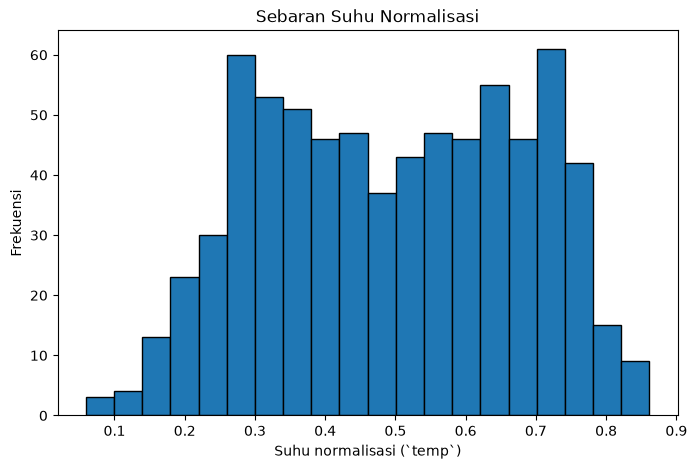

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(df["temp"], bins=20, edgecolor="black")
plt.title("Sebaran Suhu Normalisasi")
plt.xlabel("Suhu normalisasi (`temp`)")
plt.ylabel("Frekuensi")
plt.show()

### Interpretasi Histogram `temp`

Histogram digunakan untuk melihat bagaimana nilai suhu normalisasi tersebar pada seluruh hari pengamatan.

Dari histogram, kita dapat memperhatikan rentang nilai, lokasi konsentrasi data, dan bentuk umum distribusinya.

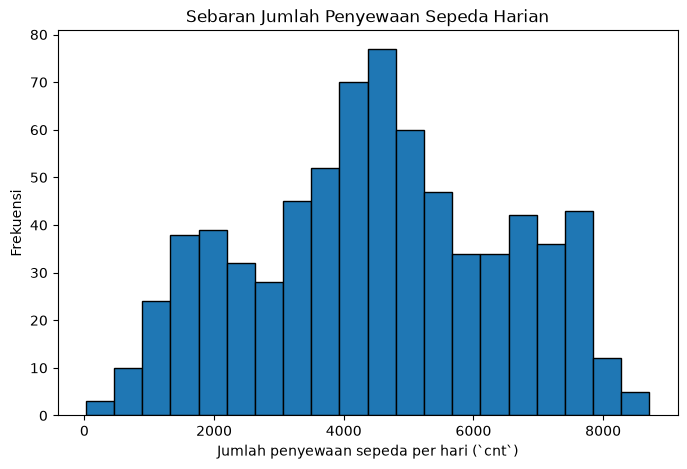

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(df["cnt"], bins=20, edgecolor="black")
plt.title("Sebaran Jumlah Penyewaan Sepeda Harian")
plt.xlabel("Jumlah penyewaan sepeda per hari (`cnt`)")
plt.ylabel("Frekuensi")
plt.show()

### Interpretasi Histogram `cnt`

Histogram `cnt` menunjukkan distribusi jumlah penyewaan sepeda pada setiap hari pengamatan.

Jumlah penyewaan memiliki rentang dari **22** sampai **8714 penyewaan per hari**.

Histogram digunakan untuk melihat konsentrasi data dan bentuk sebaran jumlah penyewaan harian.

## [8] Visualisasi — Boxplot dan Outlier

Boxplot digunakan untuk melihat median, kuartil, penyebaran data, dan kemungkinan pencilan.

Aturan pencilan yang digunakan adalah **1,5 × IQR**.

Rumus batas bawah:

\[
Batas Bawah = Q1 - 1.5(IQR)
\]

Rumus batas atas:

\[
Batas Atas = Q3 + 1.5(IQR)
\]

Sebuah observasi disebut outlier menurut aturan ini apabila nilainya berada di bawah batas bawah atau di atas batas atas.

Q1 = 3152.0
Q3 = 5956.0
IQR = 2804.0
Batas bawah = -1054.0
Batas atas = 10162.0
Jumlah pencilan = 0


C:\Users\ZakirIT\AppData\Local\Temp\ipykernel_472\180244805.py:20: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["cnt"], vert=True)


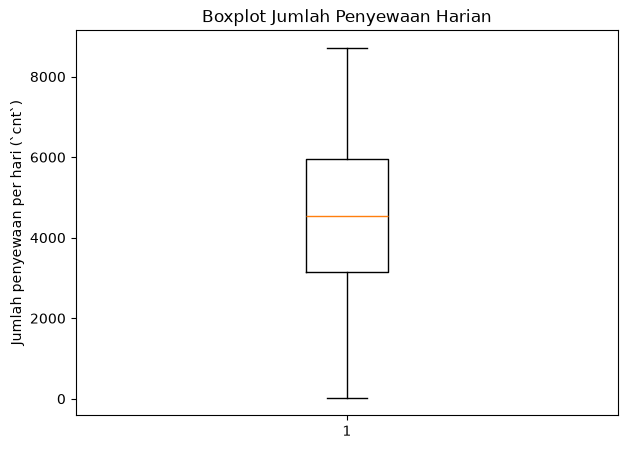

In [15]:
kolom = df["cnt"]

q1 = kolom.quantile(0.25)
q3 = kolom.quantile(0.75)
iqr = q3 - q1

batas_bawah = q1 - 1.5 * iqr
batas_atas = q3 + 1.5 * iqr

outlier = df[(df["cnt"] < batas_bawah) | (df["cnt"] > batas_atas)]

print("Q1 =", q1)
print("Q3 =", q3)
print("IQR =", iqr)
print("Batas bawah =", batas_bawah)
print("Batas atas =", batas_atas)
print("Jumlah pencilan =", len(outlier))

plt.figure(figsize=(7, 5))
plt.boxplot(df["cnt"], vert=True)
plt.title("Boxplot Jumlah Penyewaan Harian")
plt.ylabel("Jumlah penyewaan per hari (`cnt`)")
plt.show()

### Interpretasi Boxplot

Untuk variabel `cnt` diperoleh:

- Q1 = **3152**
- Q3 = **5956**
- IQR = **2804**
- Batas bawah = **−1054**
- Batas atas = **10162**

Nilai minimum `cnt` adalah **22**, sedangkan nilai maksimum adalah **8714**.

Walaupun nilai 22 dan 8714 terlihat sangat berjauhan, keduanya masih berada di dalam batas pencilan −1054 sampai 10162.

Jadi, berdasarkan **aturan 1,5 × IQR**, tidak ditemukan outlier pada variabel `cnt`.

## [9] Visualisasi — Diagram Batang

Diagram batang digunakan untuk menampilkan distribusi variabel kategorik `season\_label`.

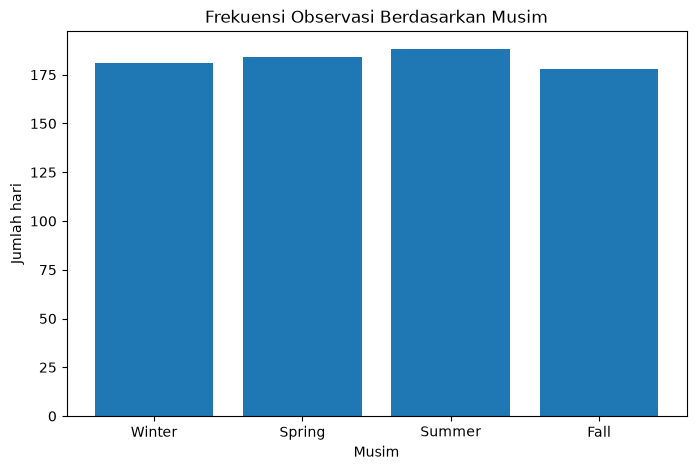

In [16]:
urutan_musim = ["Winter", "Spring", "Summer", "Fall"]

season_counts = df["season_label"].value_counts().reindex(urutan_musim)

plt.figure(figsize=(8, 5))
plt.bar(season_counts.index, season_counts.values)
plt.title("Frekuensi Observasi Berdasarkan Musim")
plt.xlabel("Musim")
plt.ylabel("Jumlah hari")
plt.show()

### Interpretasi Diagram Batang

Jumlah observasi pada setiap musim relatif berdekatan, yaitu sekitar 178–188 hari.

Summer memiliki jumlah observasi paling banyak, yaitu 188 hari, sedangkan Fall memiliki jumlah observasi paling sedikit, yaitu 178 hari.

Grafik ini menunjukkan **jumlah hari pengamatan** pada setiap musim, bukan jumlah penyewaan sepeda.

## [10] Perbandingan Jumlah Penyewaan per Musim

Sebagai analisis tambahan, dilakukan perbandingan statistik jumlah penyewaan (`cnt`) berdasarkan musim.

Tujuannya adalah melihat apakah jumlah penyewaan harian memiliki pola yang berbeda pada setiap musim.

In [17]:
ringkasan_musim = (
    df.groupby("season_label")["cnt"]
    .agg(["count", "mean", "median", "min", "max"])
    .reindex(urutan_musim)
)

ringkasan_musim

,count,mean,median,min,max
season_label,,,,,
Winter,181,2604.132597,2209.0,431,7836
Spring,184,4992.331522,4941.5,795,8362
Summer,188,5644.303191,5353.5,1115,8714
Fall,178,4728.162921,4634.5,22,8555


### Interpretasi Per Musim

Rata-rata jumlah penyewaan harian berbeda antar-musim.

Sebagai pengecekan, nilai rata-rata `cnt` kira-kira:

- Winter ≈ **2604 penyewaan/hari**
- Spring ≈ **4992 penyewaan/hari**
- Summer ≈ **5644 penyewaan/hari**
- Fall ≈ **4728 penyewaan/hari**

Berdasarkan statistik deskriptif tersebut, rata-rata penyewaan pada dataset ini berbeda menurut musim.

Angka tersebut hanya menggambarkan data pada sistem bike sharing dan periode yang terdapat dalam dataset, sehingga tidak dapat langsung dianggap mewakili seluruh kota atau seluruh sistem bike sharing.

## [11] Scatter Plot `temp` vs `cnt`

Scatter plot digunakan untuk melihat pola visual antara dua variabel numerik:

- `temp` = suhu normalisasi
- `cnt` = jumlah penyewaan sepeda

Visualisasi ini digunakan untuk melihat apakah terdapat pola tertentu antara kedua variabel tersebut.

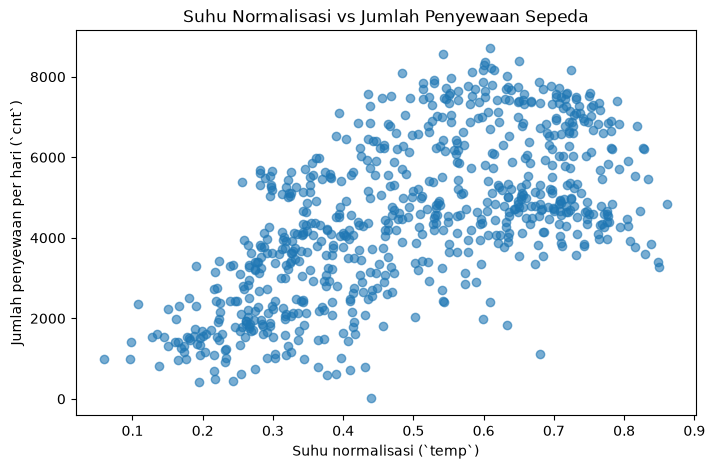

In [18]:
plt.figure(figsize=(8, 5))
plt.scatter(df["temp"], df["cnt"], alpha=0.6)
plt.title("Suhu Normalisasi vs Jumlah Penyewaan Sepeda")
plt.xlabel("Suhu normalisasi (`temp`)")
plt.ylabel("Jumlah penyewaan per hari (`cnt`)")
plt.show()

### Interpretasi Scatter Plot

Scatter plot menunjukkan adanya kecenderungan visual bahwa pada sebagian rentang suhu yang lebih tinggi terdapat jumlah penyewaan yang lebih tinggi.

Namun, scatter plot ini hanya digunakan untuk melihat **pola visual**.

Dari grafik ini kami belum menyatakan bahwa suhu menyebabkan perubahan jumlah penyewaan, karena Project 1 belum melakukan uji korelasi.

## [12] Kesimpulan

### Jawaban Pertanyaan Analisis

**1. Bagaimana pusat dan penyebaran jumlah penyewaan sepeda (`cnt`)?**

Rata-rata jumlah penyewaan sepeda adalah sekitar **4504,35 penyewaan per hari**, sedangkan median adalah **4548 penyewaan per hari**. Nilai minimum adalah 22 dan maksimum adalah 8714 sehingga range sebesar **8692**. Q1 = 3152 dan Q3 = 5956 sehingga IQR = **2804**. Simpangan baku sekitar **1937,21**.

**2. Bagaimana jumlah penyewaan berbeda menurut musim?**

Rata-rata jumlah penyewaan harian berbeda antar-musim. Rata-rata sekitar **2604 penyewaan/hari** pada Winter, **4992** pada Spring, **5644** pada Summer, dan **4728** pada Fall.

**3. Bagaimana pola hubungan yang terlihat antara `temp` dan `cnt`?**

Scatter plot menunjukkan adanya kecenderungan visual bahwa pada sebagian rentang suhu yang lebih tinggi terdapat jumlah penyewaan yang lebih tinggi.

### Temuan Utama

1. Jumlah penyewaan harian memiliki rentang yang lebar, yaitu dari 22 sampai 8714 penyewaan.
2. Mean `cnt` sekitar 4504,35 dan median sebesar 4548.
3. Sebanyak 50% data `cnt` berada antara 3152 dan 5956 penyewaan per hari.
4. Rata-rata jumlah penyewaan berbeda antar-musim.
5. Scatter plot `temp` dan `cnt` menunjukkan pola visual yang dapat dianalisis lebih lanjut.

### Keterbatasan Data

- Data hanya mencakup tahun 2011–2012.
- Dataset berasal dari satu sistem bike sharing.
- Beberapa variabel cuaca disimpan dalam bentuk normalisasi.

## [13] Referensi dan Catatan Penggunaan AI

### Referensi Utama

1. UCI Machine Learning Repository. **Bike Sharing Dataset**.
   https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

2. Fanaee-T, H. (2013). **Bike Sharing Dataset**.
   https://doi.org/10.24432/C5W894


### Catatan Penggunaan AI

| Alat | Dipakai untuk | Yang Kami Pelajari |
|---|---|---|
| ChatGPT | Membantu setup Jupyter Notebook dan memahami syntax Python | Kami mempelajari bagaimana cara setup Jupyter Notebook dengan benar dan bagaimana syntax python |
| ChatGPT | Meminta contoh kode untuk data lain | Kami mempelajari bagaimana cara menulis ulang kode tersebut secara mandiri agar sesuai dengan data yang kami gunakan pada proyek ini |